# 3. Customer Segmentation

## Setup

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# Display numbers
pd.options.display.float_format = '{:20.2f}'.format
def millions_formatter(x, pos):
    return f'£{x/1e6:.1f}M'

# Show all columns
pd.set_option('display.max_columns', None)

#### Visualization settings

In [58]:
# setting theme
sns.set_theme(
    style='white',
    font='sans-serif',
    rc={
        'axes.spines.top':    False,
        'axes.spines.right':  False,
        'axes.grid':          True,
        'grid.color':         '#F1EFE8',
        'grid.linewidth':     0.8,
        'axes.facecolor':     'white',
        'axes.titleweight': 'bold',
        'figure.facecolor':   'white',
        'axes.labelcolor':    '#444441',
        'xtick.color':        '#444441',
        'ytick.color':        '#444441',
        'axes.titlesize':     13,
        'axes.labelsize':     11,
        'xtick.labelsize':    10,
        'ytick.labelsize':    10,
        'figure.titlesize':   14,
    }
)

# setting colors
color_assign = {
    'Cluster 5':            '#5C74B8',
    'Cluster 0':            '#7A5CB8',
    'Cluster 1':            '#3DA898',
    'Cluster 3':            '#C95555',
    'Cluster 2':            '#D4853A',
    'Cluster 4':            '#B84E6E'
}

color_assign_segment = {
    'New':                  '#5C74B8',
    'Occasional':           '#7A5CB8',
    'Inactive':             '#3DA898',
    'Lost':                 '#C95555',
    'Champions':            '#D4853A',
    'VIP':                  '#B84E6E'
}


## Data Preparation

#### Loading Data

In [59]:
df_cleaned = pd.read_csv('../datasets/01_cleaned_data.csv')
df_clustered = pd.read_csv('../datasets/02_clustered_customers.csv')
df_rfm = pd.read_csv('../datasets/01_rfm_df.csv')

In [60]:
# Checking datasets
print("Cleaned transactions:")
df_cleaned.info()

print("\nClustered customers:")
df_clustered.info()

print("\nRFM customers:")
df_rfm.info()

Cleaned transactions:
<class 'pandas.DataFrame'>
RangeIndex: 385734 entries, 0 to 385733
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   InvoiceNo      385734 non-null  int64  
 1   Description    385734 non-null  str    
 2   InvoiceDate    385734 non-null  str    
 3   CustomerID     385734 non-null  int64  
 4   Country        385734 non-null  str    
 5   Quantity       385734 non-null  int64  
 6   UnitPrice      385734 non-null  float64
 7   TransactionID  385734 non-null  str    
 8   TotalPrice     385734 non-null  float64
dtypes: float64(2), int64(3), str(4)
memory usage: 49.5 MB

Clustered customers:
<class 'pandas.DataFrame'>
RangeIndex: 4270 entries, 0 to 4269
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     4270 non-null   int64  
 1   Recency        4270 non-null   int64  
 2   Frequency      4270 non-nul

#### Merging data

In [61]:
# Merge datasets
df = df_cleaned.merge(
    df_clustered[['CustomerID','Cluster', 'Cluster_Label', 'Recency', 'Frequency', 'Monetary']], 
    on='CustomerID', 
    how='left'
)

In [62]:
# Checking NaN values
print(df.isnull().sum())

InvoiceNo            0
Description          0
InvoiceDate          0
CustomerID           0
Country              0
Quantity             0
UnitPrice            0
TransactionID        0
TotalPrice           0
Cluster          55525
Cluster_Label    55525
Recency          55525
Frequency        55525
Monetary         55525
dtype: int64


The df_clustered dataset contains only the customers retained after the clustering and outlier treatment process.     
Therefore, customers excluded during that process are not present in df_clustered.    
When df_clustered was merged with df_cleaned using a left join, all transactions from df_cleaned were retained.     
As a result, customers that were not present in df_clustered had NaN values for the cluster and RFM columns.    
These missing values do not represent missing data in the original transaction dataset;     
they indicate customers that were excluded from the clustering dataset and therefore require separate handling.

#### Handling NaN values

In [63]:
# Updating RFM values from df_rfm using CustomerID

df['Recency'] = df['Recency'].fillna(
    df['CustomerID'].map(df_rfm.set_index('CustomerID')['Recency'])
)

df['Frequency'] = df['Frequency'].fillna(
    df['CustomerID'].map(df_rfm.set_index('CustomerID')['Frequency'])
)

df['Monetary'] = df['Monetary'].fillna(
    df['CustomerID'].map(df_rfm.set_index('CustomerID')['Monetary'])
)

# Renaming NaN cluster label and Nan cluster as a new cluster

df['Cluster_Label'] = df['Cluster_Label'].fillna('Cluster 4')
df['Cluster'] = df['Cluster'].fillna(4)

In [64]:
# Checking NaN values
print(df.isnull().sum())

InvoiceNo        0
Description      0
InvoiceDate      0
CustomerID       0
Country          0
Quantity         0
UnitPrice        0
TransactionID    0
TotalPrice       0
Cluster          0
Cluster_Label    0
Recency          0
Frequency        0
Monetary         0
dtype: int64


In [65]:
# Final dataset preview
df.head()

,InvoiceNo,Description,InvoiceDate,CustomerID,Country,Quantity,UnitPrice,TransactionID,TotalPrice,Cluster,Cluster_Label,Recency,Frequency,Monetary
0,536365,CREAM CUPID HEARTS COAT HANGER,2010-12-01,17850,United Kingdom,8,2.75,536365_000001,22.00,4.00,Cluster 4,372.00,34.00,5391.21
1,536365,GLASS STAR FROSTED T-LIGHT HOLDER,2010-12-01,17850,United Kingdom,6,4.25,536365_000002,25.50,4.00,Cluster 4,372.00,34.00,5391.21
2,536365,KNITTED UNION FLAG HOT WATER BOTTLE,2010-12-01,17850,United Kingdom,6,3.39,536365_000003,20.34,4.00,Cluster 4,372.00,34.00,5391.21
3,536365,RED WOOLLY HOTTIE WHITE HEART.,2010-12-01,17850,United Kingdom,6,3.39,536365_000004,20.34,4.00,Cluster 4,372.00,34.00,5391.21
4,536365,SET 7 BABUSHKA NESTING BOXES,2010-12-01,17850,United Kingdom,2,7.65,536365_000005,15.30,4.00,Cluster 4,372.00,34.00,5391.21


In [66]:
print(df.shape)

(385734, 14)


The missing RFM values were filled using the available customer-level information.
While the Cluster and Cluster label were assigned values as 4 and Cluster 4.     
These customers had previously been excluded from df_rfm during the clustering and outlier treatment process.

At this stage, two options were considered: removing these customers from the dataset or retaining them for further analysis.     
Since these customers may provide useful insights, an exploratory analysis was performed to examine their RFM distributions     
and determine whether they should be retained as a meaningful segment.





## Segment Analysis & Refinement

#### Initial RFM Cluster Assessment - 3D plot

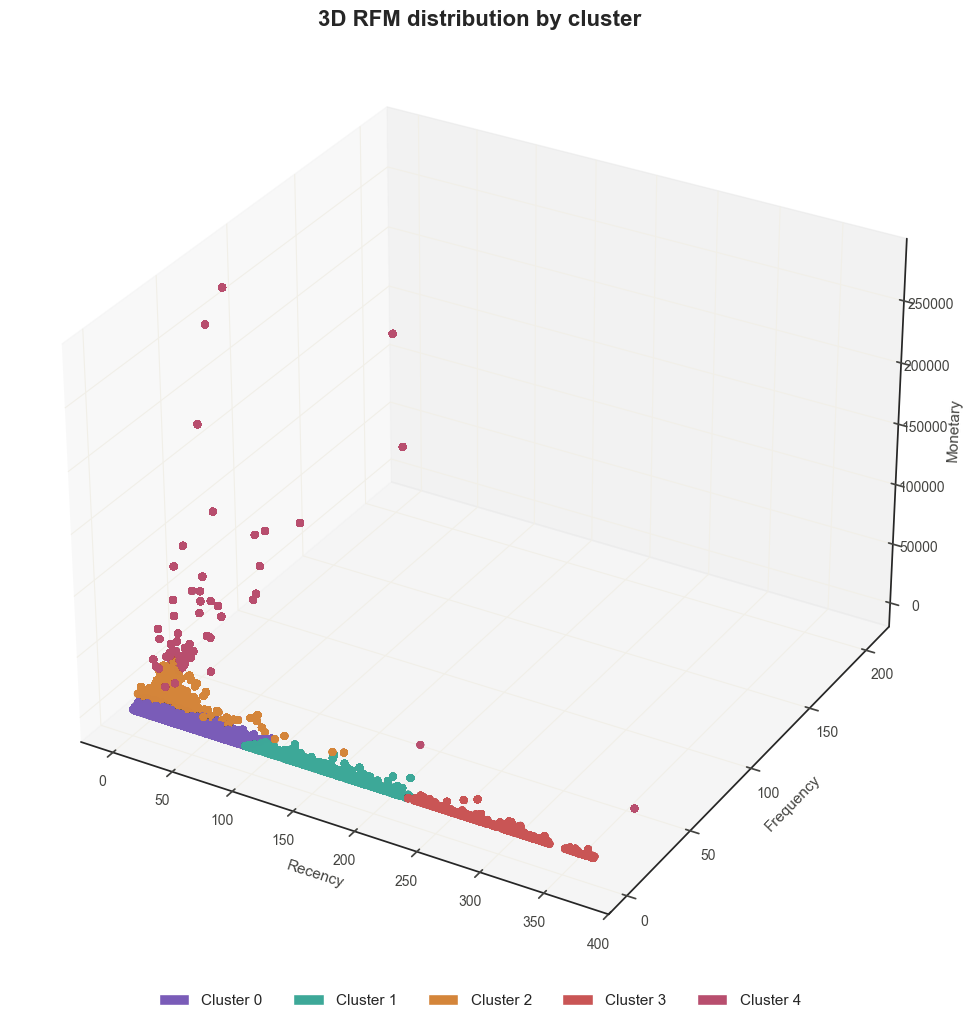

In [67]:
# Visual check of the RFM cluster distribution
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Map color per row
colors = df['Cluster_Label'].map(color_assign)

# Plotting
ax.scatter(
    df['Recency'],
    df['Frequency'],
    df['Monetary'],
    c=colors
)
# build legend from your existing color_assign dict
legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in sorted(color_assign.items())
    if label != 'Cluster 5'
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=len(legend_elements),
    bbox_to_anchor=(0.5, -0.03),
    frameon=False,
    fontsize=11
)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('3D RFM distribution by cluster', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

The 3D RFM distribution provides an initial view of how the customer clusters differ across Recency, Frequency, and Monetary value. The clusters show distinct patterns, although some overlap can be observed between groups.

The plot also highlights the cluster 4 assigned to the customers with missing cluster values (removed outliers). These outliers represent a small number of customers compared with the other clusters, but show high Monetary and Frequency values. A few data points appear to break this pattern, showing high Recency as well. These customers will be investigated further.

At the same time, the distribution suggests that some customers within the existing clusters may have distinct purchasing behaviour that could justify further segmentation. Therefore, the next step is to examine the clusters and their RFM characteristics in more detail before deciding whether additional refinement is appropriate.

#### Identifying and Assigning New Customers Cluster

In [68]:
# Filtering customers that have bought just once
one_buy = df_clustered[
    df_clustered['Frequency'] == 1
]

# Number of customers by segment
customer_count = df_clustered.groupby('Cluster_Label')['CustomerID'].nunique()

# Number of one-time buyers by segment
one_customer_count = one_buy.groupby('Cluster_Label')['CustomerID'].nunique()

# Percentage of one-time buyers
one_customer_percentage = (
    one_customer_count / customer_count * 100
).fillna(0)

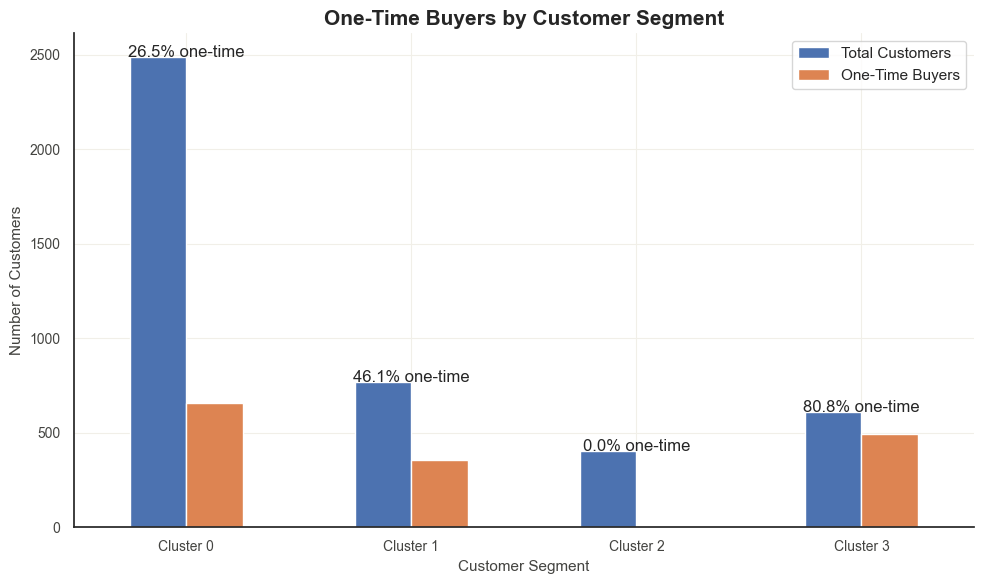

In [69]:
# Prepare data for visualization
one_buy_summary = pd.DataFrame({
    'Total Customers': customer_count,
    'One-Time Buyers': one_customer_count
}).fillna(0)

# Plot
ax = one_buy_summary.plot(
    kind='bar',
    figsize=(10, 6)
)

ax.set_title('One-Time Buyers by Customer Segment', fontsize=15, fontweight='bold')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=0)

# Add percentage labels
for i, (cluster, percentage) in enumerate(one_customer_percentage.items()):
    ax.text(
        i,
        one_buy_summary.loc[cluster, 'Total Customers'],
        f'{percentage:.1f}% one-time',
        ha='center'
    )

ax.legend(title='')
plt.tight_layout()
plt.show()

In [70]:
# Identifying cluster 0 with only one purchase and reclassifying them as Cluster 5
df.loc[(df['Cluster_Label'] == 'Cluster 0') & (df['Frequency'] == 1), 'Cluster_Label'] = 'Cluster 5'

# Assigning cluster ID 5 to the new customer segment
df.loc[df['Cluster_Label'] == 'Cluster 5', 'Cluster'] = 5

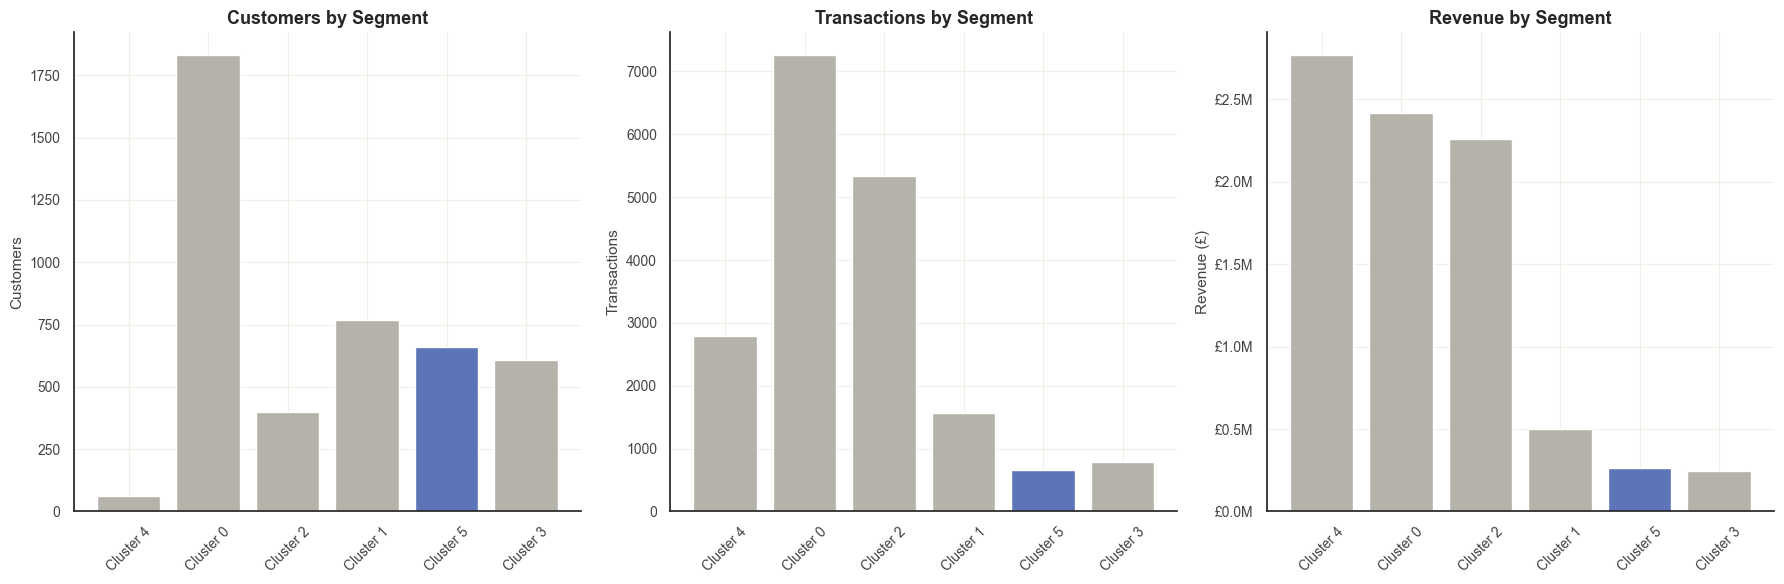

In [71]:
# Calculating customers, transactions and revenue by segment
segment_summary = df.groupby('Cluster_Label').agg(
    Customers=('CustomerID', 'nunique'),
    Transactions=('InvoiceNo', 'nunique'),
    Revenue=('TotalPrice', 'sum')
)

# Sorting segments by revenue
segment_summary = segment_summary.sort_values('Revenue', ascending=False)

# Setting colors: blue for New Customers, gray for all other segments
bar_colors = [
    '#5C74B8' if segment == 'Cluster 5' else '#B4B2A9'
    for segment in segment_summary.index
]

# Create figures
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Customers
ax1.bar(
    segment_summary.index,
    segment_summary['Customers'],
    color=bar_colors
)
ax1.set_title('Customers by Segment')
ax1.set_ylabel('Customers')
ax1.tick_params(axis='x', rotation=45)

# Transactions
ax2.bar(
    segment_summary.index,
    segment_summary['Transactions'],
    color=bar_colors
)
ax2.set_title('Transactions by Segment')
ax2.set_ylabel('Transactions')
ax2.tick_params(axis='x', rotation=45)

# Revenue
ax3.bar(
    segment_summary.index,
    segment_summary['Revenue'],
    color=bar_colors
)
ax3.set_title('Revenue by Segment')
ax3.set_ylabel('Revenue (£)')
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()

An investigation of the cluster composition was conducted to identify customers who made only one order during the entire observation period. These customers have a Frequency of 1.

One-time buyers are present in Clusters 0, 1, and 3, with Cluster 0 containing the largest number of one-time buyers (659), followed by Cluster 3 (492) and Cluster 1 (355).

Cluster 0 is particularly relevant because these one-time buyers are associated with a relatively recent purchasing pattern, while Cluster 0 also represents the largest customer group. Based on the combination of Frequency, Recency, and cluster size, one-time buyers within Cluster 0 are considered for separation into a new cluster called Cluster 5.

Note: This classification is specific to the available observation period. A Frequency value of 1 does not necessarily mean that these customers are genuinely new, as a longer observation period could reveal additional purchases. Therefore, the Cluster 5 segment should be interpreted as customers who made one purchase during the available observation period, rather than as a definitive indication that they are newly acquired customers.

#### Analysing Outliers Cluster

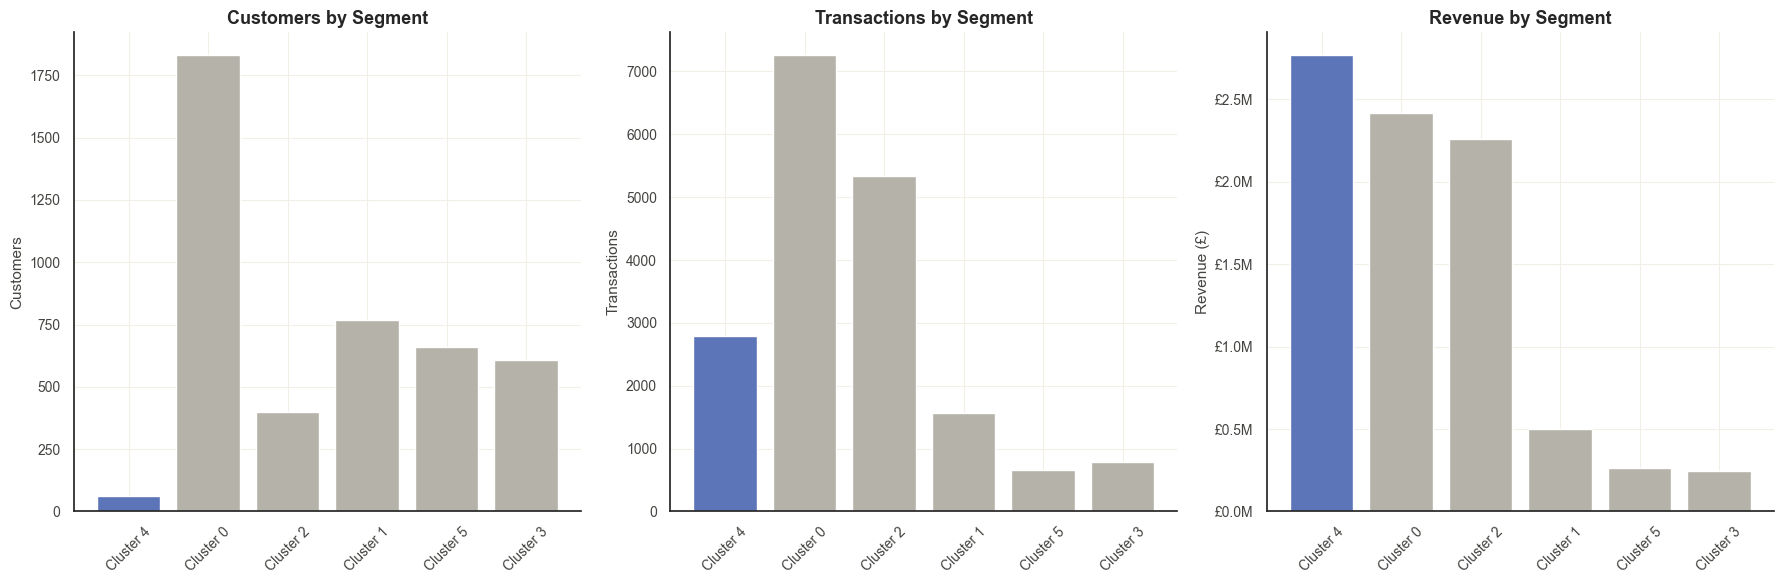

In [72]:
# Setting colors: blue for Outliers, gray for all other segments
bar_colors = [
    '#5C74B8' if segment == 'Cluster 4' else '#B4B2A9'
    for segment in segment_summary.index
]

# Create figures
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Customers
ax1.bar(
    segment_summary.index,
    segment_summary['Customers'],
    color=bar_colors
)
ax1.set_title('Customers by Segment')
ax1.set_ylabel('Customers')
ax1.tick_params(axis='x', rotation=45)

# Transactions
ax2.bar(
    segment_summary.index,
    segment_summary['Transactions'],
    color=bar_colors
)
ax2.set_title('Transactions by Segment')
ax2.set_ylabel('Transactions')
ax2.tick_params(axis='x', rotation=45)

# Revenue
ax3.bar(
    segment_summary.index,
    segment_summary['Revenue'],
    color=bar_colors
)
ax3.set_title('Revenue by Segment')
ax3.set_ylabel('Revenue (£)')
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()

The Cluster 4 contains a relatively small number of customers but a substantial    
amount of transaction activity and the highest revenue among the segments.    

The analysis shows that this cluster has a significant influence on total revenue,    
making it valuable to retain for further analysis in this study.

Text(0.5, 0, '')

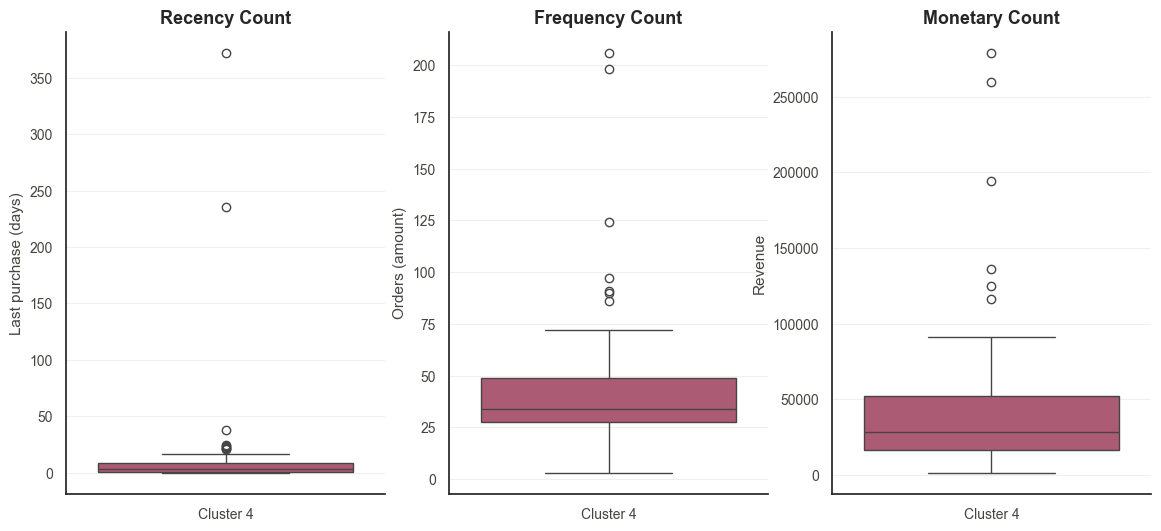

In [73]:
# Creating customer-leve RFM dataset
df_customer_rfm = df.groupby('CustomerID').agg(
    Recency=('Recency', 'first'),
    Frequency=('Frequency', 'first'),
    Monetary=('Monetary', 'first'),
    Cluster_Label=('Cluster_Label', 'first')
).reset_index()

# Selecting customers in the Outliers Cluster
outlier_filtering = df_customer_rfm[df_customer_rfm['Cluster_Label'] == 'Cluster 4']


# setting figures
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))

# boxplot plot
sns.boxplot(
    data=outlier_filtering,
    x='Cluster_Label',
    y='Recency',
    hue='Cluster_Label',
    palette=color_assign,
    legend=False,
    ax=ax1
)
ax1.set_title('Recency Count')
ax1.set_ylabel('Last purchase (days)')
ax1.set_xlabel('')


sns.boxplot(
    data=outlier_filtering,
    x='Cluster_Label',
    y='Frequency',
    hue='Cluster_Label',
    palette=color_assign,
    legend=False,
    ax=ax2
)
ax2.set_title('Frequency Count')
ax2.set_ylabel('Orders (amount)')
ax2.set_xlabel('')


sns.boxplot(
    data=outlier_filtering,
    x='Cluster_Label',
    y='Monetary',
    hue='Cluster_Label',
    palette=color_assign,
    legend=False,
    ax=ax3
)
ax3.set_title('Monetary Count')
ax3.set_ylabel('Revenue')
ax3.set_xlabel('')


Most customers in the Cluster 4 have purchased recently, while also showing high purchase frequency and monetary value.

The main deviation from this pattern is two observations with substantially higher Recency values. The Frequency and Monetary distributions appear consistent with the overall cluster, while these two Recency observations are noticeably distant from the remaining customers.

These two observations will be identified in the dataframe and removed from the cluster.

In [74]:
# Identifying the two high-Recency observations for removal
extreme_outliers = outlier_filtering[outlier_filtering['Recency'] > 100]
extreme_outliers

,CustomerID,Recency,Frequency,Monetary,Cluster_Label
2501,15749,235.00,3.00,44534.30,Cluster 4
4011,17850,372.00,34.00,5391.21,Cluster 4


In [75]:
# Removal on rfm to check distribution
outliers_removed = outlier_filtering[outlier_filtering['Recency'] <= 100]

print(f'customer number before: {len(outlier_filtering)}')
print(f'customer number after:  {len(outliers_removed)}')

# Compare Recency before and after removal
recency_comparison = pd.DataFrame({
    'Before': outlier_filtering['Recency'].agg(['mean', 'median']),
    'After': outliers_removed['Recency'].agg(['mean', 'median'])
}).round(2)

recency_comparison

customer number before: 63
customer number after:  61


,Before,After
mean,15.70,6.26
median,3.00,3.00


The comparison shows that removing the two high-Recency observations brings the Recency distribution closer to the overall pattern of the Cluster 4, while the change in the median remains limited. Based on this validation, the two observations will be removed from the original merged dataset so that the final dataset reflects the revised Cluster 4.

In [76]:
# Identifying customers to remove
outlier_customer_ids = extreme_outliers['CustomerID']

print(f'Customers to remove: {len(outlier_customer_ids)}')

# Removing from the merged transaction dataset
df = df[
    ~df['CustomerID'].isin(outlier_customer_ids)
].reset_index(drop=True)

# Removing from the customer-level RFM dataset
df_customer_rfm = df_customer_rfm[
    ~df_customer_rfm['CustomerID'].isin(outlier_customer_ids)
].reset_index(drop=True)

print(f'Final dataset shape: {df.shape}\nFinal customer dataset shape: {df_customer_rfm.shape}')

Customers to remove: 2
Final dataset shape: (385427, 14)
Final customer dataset shape: (4331, 5)


## Segment Profiling & Overview

#### RFM distribution

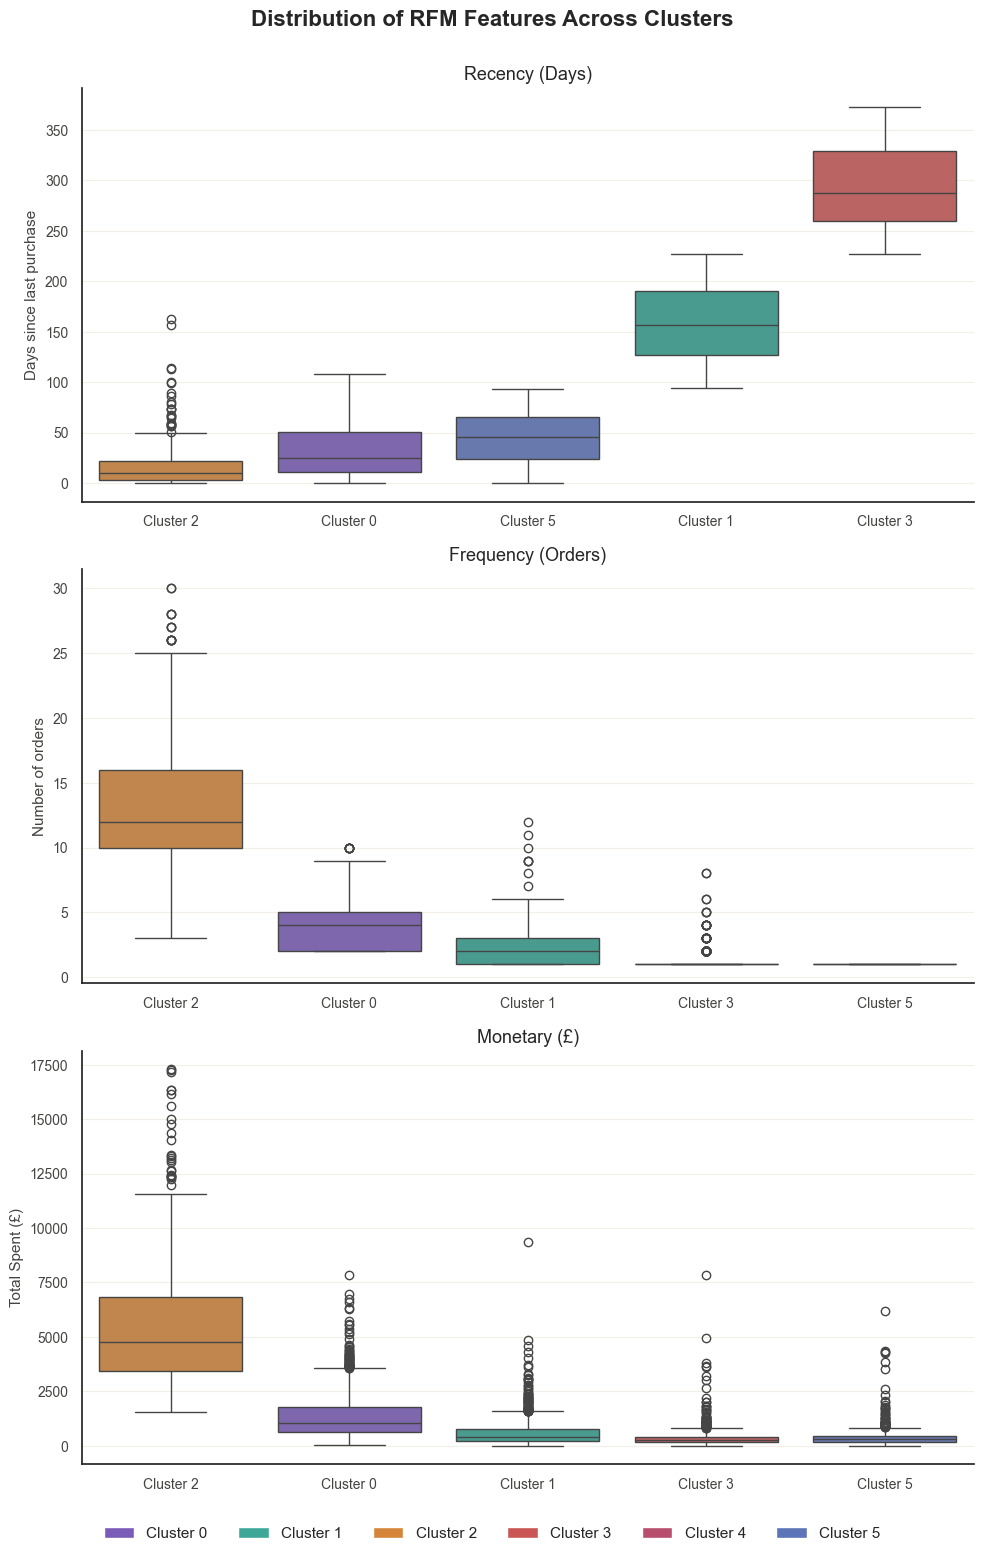

In [77]:
# Creating final customer-level RFM dataset without the Outlier Cluster
df_no_outlier = df_customer_rfm[
    ~(
        (df_customer_rfm['Cluster_Label'] == 'Cluster 4')
    )
].copy()

# Setting figures
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

# Recency boxplot
sns.boxplot(
    data=df_no_outlier,
    x='Cluster_Label',
    y='Recency',
    hue='Cluster_Label',
    palette=color_assign,
    order=df_no_outlier.groupby('Cluster_Label')['Recency'].mean().sort_values().index,
    legend=False,
    ax=ax1
)

ax1.set_title('Recency (Days)', fontweight='normal')
ax1.set_xlabel('')
ax1.set_ylabel('Days since last purchase')

# Frequency boxplot
sns.boxplot(
    data=df_no_outlier,
    x='Cluster_Label',
    y='Frequency',
    hue='Cluster_Label',
    palette=color_assign,
    order=df_no_outlier.groupby('Cluster_Label')['Frequency'].mean().sort_values(ascending=False).index,
    legend=False,
    ax=ax2
)

ax2.set_title('Frequency (Orders)', fontweight='normal')
ax2.set_xlabel('')
ax2.set_ylabel('Number of orders')

# Monetary boxplot
sns.boxplot(
    data=df_no_outlier,
    x='Cluster_Label',
    y='Monetary',
    hue='Cluster_Label',
    palette=color_assign,
    order=df_no_outlier.groupby('Cluster_Label')['Monetary'].mean().sort_values(ascending=False).index,
    legend=False,
    ax=ax3
)

ax3.set_title('Monetary (£)', fontweight='normal')
ax3.set_xlabel('')
ax3.set_ylabel('Total Spent (£)')


# building legend from the existing color_assign dict
legend_elements = [
    Patch(facecolor=color, label=label) 
    for label, color in sorted(color_assign.items())
    if label != 'Outliers'
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=len(legend_elements),
    bbox_to_anchor=(0.5, -0.03),
    frameon=False,
    fontsize=11
)

plt.suptitle(
    'Distribution of RFM Features Across Clusters',
    fontsize=16,
    fontweight='bold',
    y=1
)

plt.tight_layout()
plt.show()

The outlier cluster was excluded from this boxplot because its value would make the other segment distributions more difficult to analyse:  
- Recency: Cluster 0 and Cluster 2 are, on average, the most recent buyers, while Cluster 3 customers have not purchased for a long period.
- Frequency: Cluster 2 have the highest number of orders, followed by Cluster 0. Cluster 5 show no distribution because they have made only one purchase.   
- Monetary: Monetary represents the total value generated by each cluster and follows a similar pattern to frequency, with Cluster 2 and Cluster 0 with the highest values followed by Cluster 1, 3 and Cluster 5.

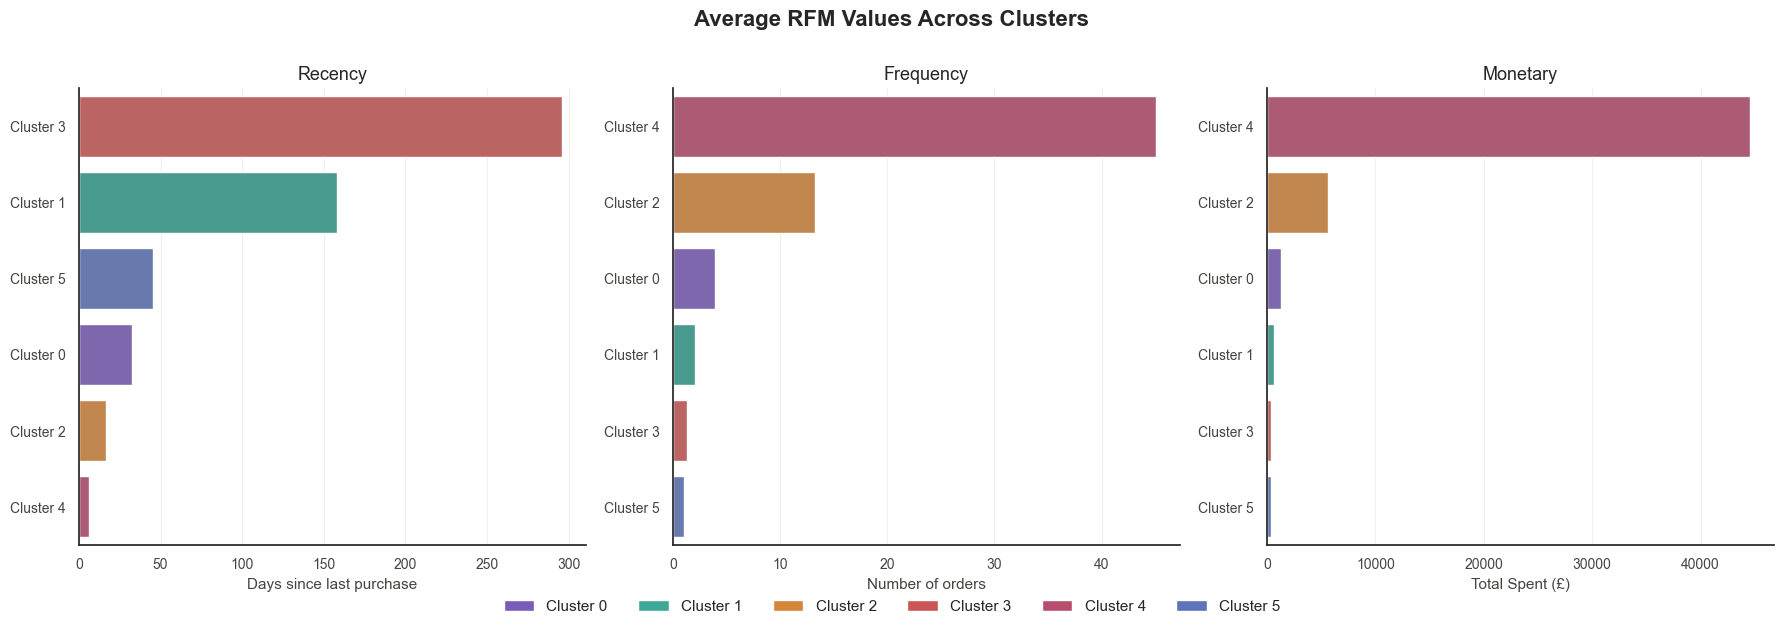

In [78]:
# Calculating average RFM values by cluster
recency_mean = (
    df_customer_rfm.groupby('Cluster_Label')['Recency']
    .mean()
    .sort_values(ascending=False)
)

frequency_mean = (
    df_customer_rfm.groupby('Cluster_Label')['Frequency']
    .mean()
    .sort_values(ascending=False)
)

monetary_mean = (
    df_customer_rfm.groupby('Cluster_Label')['Monetary']
    .mean()
    .sort_values(ascending=False)
)


# Setting figures
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Recency barplot
sns.barplot(
    y=recency_mean.index,
    x=recency_mean.values,
    hue=recency_mean.index,
    palette=color_assign,
    legend=False,
    ax=ax1
)

ax1.set_title('Recency', fontweight='normal')
ax1.set_xlabel('Days since last purchase')
ax1.set_ylabel('')

# Frequency barplot
sns.barplot(
    y=frequency_mean.index,
    x=frequency_mean.values,
    hue=frequency_mean.index,
    palette=color_assign,
    legend=False,
    ax=ax2
)

ax2.set_title('Frequency', fontweight='normal')
ax2.set_xlabel('Number of orders')
ax2.set_ylabel('')

# Monetary barplot
sns.barplot(
    y=monetary_mean.index,
    x=monetary_mean.values,
    hue=monetary_mean.index,
    palette=color_assign,
    legend=False,
    ax=ax3
)

ax3.set_title('Monetary', fontweight='normal')
ax3.set_xlabel('Total Spent (£)')
ax3.set_ylabel('')

# building legend from the color_assign dict
legend_elements = [Patch(facecolor=color, label=label) 
                   for label, color in sorted(color_assign.items())
                   ]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=len(legend_elements),
    bbox_to_anchor=(0.5, -0.03),
    frameon=False,
    fontsize=11
)

plt.suptitle(
    'Average RFM Values Across Clusters',
    fontsize=16,
    fontweight='bold',
    y=1
)

plt.tight_layout()
plt.show()

This chart compares the average RFM values across all clusters, including Cluster 4.

Cluster 4 has the highest average Frequency and Monetary value, with customers making more than 40 orders on average and generating substantially higher monetary value than the other clusters.      
It also has the lowest average Recency, meaning their most recent purchases occurred more recently than those of the other clusters. Together, these results indicate a highly valuable and recently engaged customer group.

In [79]:
# RFM table with statistic information about each cluster
df_customer_rfm.groupby('Cluster_Label')[['Recency', 'Frequency', 'Monetary']]\
    .agg(['count','mean', 'median', 'min', 'max', 'std'])\
    .round(2)

Recency                                            \
                count                 mean               median   
Cluster_Label                                                     
Cluster 0        1831                32.76                25.00   
Cluster 1         770               158.25               157.00   
Cluster 2         401                16.67                10.00   
Cluster 3         609               295.80               288.00   
Cluster 4          61                 6.26                 3.00   
Cluster 5         659                45.43                46.00   

                                                                              \
                               min                  max                  std   
Cluster_Label                                                                  
Cluster 0                     0.00               108.00                25.87   
Cluster 1                    94.00               227.00                37.56   
Cluster 2                     0.00               163.00                21.13   
Cluster 3                   227.00               373.00                44.17   
Cluster 4                     0.00                38.00                 7.83   
Cluster 5                     0.00                93.00                24.66   

              Frequency                                            \
                  count                 mean               median   
Cluster_Label                                                       
Cluster 0          1831                 3.96                 4.00   
Cluster 1           770                 2.04                 2.00   
Cluster 2           401                13.30                12.00   
Cluster 3           609                 1.29                 1.00   
Cluster 4            61                45.07                34.00   
Cluster 5           659                 1.00                 1.00   

                                                                              \
                               min                  max                  std   
Cluster_Label                                                                  
Cluster 0                     2.00                10.00                 1.91   
Cluster 1                     1.00                12.00                 1.41   
Cluster 2                     3.00                30.00                 5.18   
Cluster 3                     1.00                 8.00                 0.78   
Cluster 4                     6.00               206.00                36.91   
Cluster 5                     1.00                 1.00                 0.00   

              Monetary                                            \
                 count                 mean               median   
Cluster_Label                                                      
Cluster 0         1831              1318.44              1043.41   
Cluster 1          770               646.75               416.54   
Cluster 2          401              5640.39              4762.32   
Cluster 3          609               404.04               280.55   
Cluster 4           61             44551.23             28117.04   
Cluster 5          659               396.40               290.66   

                                                                              
                               min                  max                  std  
Cluster_Label                                                                 
Cluster 0                    36.56              7829.89               983.54  
Cluster 1                     2.90              9341.26               724.03  
Cluster 2                  1535.77             17286.86              3165.79  
Cluster 3                     3.75              7832.47               560.74  
Cluster 4                  1296.44            279138.02             54618.56  
Cluster 5                     5.90              6207.67               506.12

Based on the RFM averages and distributions above, each cluster was named 
according to its purchasing behaviour:

**Cluster 0 — Occasional**  
Low recency, third highest frequency and monetary. About 4 orders/year, 
~£1,300 average spend. Active but mostly average across the board compared 
to other clusters.

**Cluster 1 — Inactive**  
Second highest recency, low frequency and monetary. Average of 2 orders, 
last purchase ~5 months ago. Spent about half of Cluster 0, but still more 
than Cluster 3.

**Cluster 2 — Champions**  
Highest monetary and frequency (excluding the outlier cluster), lowest 
recency at ~2 weeks since last order. Most active, high-value segment.

**Cluster 3 — Lost**  
Similar frequency/monetary to Cluster 5, but highest recency — average of 
~1 purchase, last bought almost 9 months ago on a one-year dataset. Mostly 
one-time buyers who haven't returned.

**Cluster 4 — VIP**
Small number of customers, but lowest recency and much higher monetary/frequency 
than Cluster 2. Disproportionate contribution to revenue and order frequency 
despite being a small share of the customer base.

**Cluster 5 — New**  
Similar monetary/frequency to Cluster 3, but recent — frequency of 1, recency 
~45 days. Made their only purchase recently, consistent with a new customer.

Six segments in total, each with a distinct RFM profile.

#### Profiling Clusters into Customer Segments


In [80]:
# Profiling/Renaming each cluster label to proper customer segments
df['Cluster_Label'] = df['Cluster_Label'].replace(
    {
        'Cluster 0':'Occasional',
        'Cluster 1':'Inactive',
        'Cluster 2':'Champions',
        'Cluster 3':'Lost',
        'Cluster 4':'VIP',
        'Cluster 5':'New'
    }
)

In [81]:
# Checking LineItems total records by each segment
df['Cluster_Label'].value_counts()

Cluster_Label
Occasional    158531
Champions     112615
VIP            55218
Inactive       28817
New            16405
Lost           13841
Name: count, dtype: int64

#### Segments overview distributions

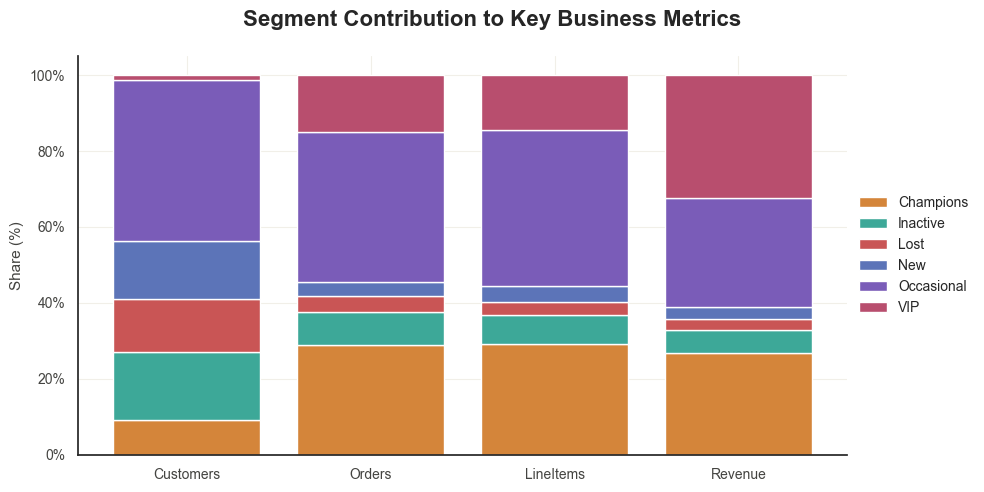

In [82]:
# Calculating segment metrics
df_segments = df.groupby('Cluster_Label').agg(
    Customers=('CustomerID', 'nunique'),
    Orders=('InvoiceNo', 'nunique'),
    LineItems = ('TransactionID', 'nunique'),
    Revenue=('TotalPrice', 'sum')
).reset_index().set_index('Cluster_Label')

# Calculating percentages
df_pct = df_segments.div(df_segments.sum(axis=0), axis=1) * 100

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(df_pct.columns))

for segment, row in df_pct.iterrows():
    color = color_assign_segment.get(segment, '#888780')
    ax.bar(df_pct.columns, row.values, bottom=bottom,
           label=segment, color=color)
    bottom += row.values

ax.set_ylabel('Share (%)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=10)

plt.suptitle('Segment Contribution to Key Business Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- **Occasional** is the largest segment across nearly every metric — customer 
  count, orders, and line items — but its revenue share is proportional to 
  its size, not disproportionate.
- **VIP and Champions** have the smallest customer base combined, yet 
  contribute the largest share of total revenue (~59% together) — a small 
  group of customers driving a large share of the business.
- **Inactive** is the second-largest segment by customer count, but 
  contributes little in orders or revenue — a large group with weak engagement.
- **New and Lost** are the smallest by volume across most metrics, sitting 
  at the opposite end from Occasional.

Overall, revenue is spread across three main groups (Champions, VIP, 
Occasional) rather than concentrated in one — a healthier distribution than 
if a single segment dominated total revenue.

#### Exporting Dataset for Association Rules

In [83]:
# Saving dataset
df.to_csv('../datasets/03_customer_segments.csv', index=False)

## 